# Projeto Individual 1 — RNAP / PPMEC0070 (2026.2)

**Autor:** Ronen Rodrigues Silva Filho — PPMEC/UnB

**Enunciado:** implementar, treinar e avaliar um modelo de linguagem autoregressivo, similar ao GPT-2, treinado com as obras de Machado de Assis.

**Autoria do código — resumo (detalhado em cada seção abaixo):**
- Base do modelo/treinamento: [`nanoGPT`](https://github.com/karpathy/nanoGPT), de **Andrej Karpathy** (código de terceiro, usado como pede o enunciado do projeto).
- Coleta e montagem do corpus de Machado de Assis: **script próprio**, a partir de duas fontes de domínio público — [Project Gutenberg](https://www.gutenberg.org/) (12 livros) e [Wikisource em português](https://pt.wikisource.org/) (~1780 páginas adicionais: contos avulsos, crônicas, poesia, crítica, teatro, capítulos de romance) — corpus final de ~13,9M caracteres.
- Adaptação da tokenização em nível de caractere e da config de treino para o corpus de Machado: **adaptação própria** do `data/shakespeare_char/prepare.py` e `config/train_shakespeare_char.py` originais do nanoGPT.
- Geração das figuras (composição do corpus, diagrama de arquitetura, cronograma de learning rate, curvas de loss/perplexidade): **código próprio**, salvas em `figuras/` durante a execução deste notebook.

**Referências teóricas:**
- Vaswani et al., *Attention Is All You Need* — https://arxiv.org/abs/1706.03762
- Brown et al., *Language Models are Few-Shot Learners* (GPT-3) — https://arxiv.org/abs/2005.14165
- Andrej Karpathy, *Let's build GPT: from scratch, in code, spelled out* — https://www.youtube.com/watch?v=kCc8FmEb1nY

## 0. Setup do ambiente

Roda tanto no **Google Colab com GPU** (`Ambiente de execução > Alterar tipo de ambiente de execução > GPU`, T4 ou melhor) quanto **localmente num Macbook Apple Silicon** (usa o acelerador MPS/Metal automaticamente) ou em CPU pura (mais lento, mas funciona) — a célula abaixo detecta o hardware disponível e ajusta `device`/`compile` sozinha, sem precisar editar nada à mão.

In [1]:
# [código de terceiros] clona o repositório nanoGPT (Andrej Karpathy) — código base pedido no enunciado
# (idempotente: pula clone/cd se já estiver dentro da pasta, útil ao reexecutar localmente)
import os
if os.path.basename(os.getcwd()) != "nanoGPT":
    if not os.path.isdir("nanoGPT"):
        !git clone https://github.com/karpathy/nanoGPT.git

    # [código próprio] dois patches de compatibilidade no train.py original, aplicados uma única
    # vez (idempotente) e seguros tanto no Colab (CUDA) quanto no Mac (MPS/CPU):
    #
    # 1) device_type: o original só reconhece 'cuda' (`device_type = 'cuda' if 'cuda' in device
    #    else 'cpu'`), então no Mac caía em 'cpu' e NUNCA usava autocast/mixed precision —
    #    treinava sempre em float32 puro. Corrige pra reconhecer 'mps' também (não muda nada em
    #    CUDA/CPU). Testado isoladamente: ~17% mais rápido nas camadas MLP no MPS, praticamente
    #    neutro na atenção — ganho líquido esperado é modesto, não dramático.
    #
    # 2) GradScaler: o original usa a API antiga (`torch.cuda.amp.GradScaler`), que gera
    #    `FutureWarning` de depreciação em qualquer versão recente de PyTorch (é o warning visto
    #    no Colab) e é hardcoded pra CUDA. Troca pra `torch.amp.GradScaler(device_type, ...)`
    #    (API atual) e mantém `enabled=False` fora de CUDA de forma explícita — no MPS/CPU o
    #    scaler simplesmente não é usado (equivalente ao comportamento anterior, que dependia do
    #    autodesligamento silencioso da versão antiga fora de CUDA). Se a loss virar nan numa
    #    rodada em MPS, é sinal de instabilidade de fp16 sem scaler; reverta removendo este patch.
    train_py_path = os.path.join("nanoGPT", "train.py")
    with open(train_py_path, "r") as f:
        _train_src = f.read()
    _patches = [
        (
            "device_type = 'cuda' if 'cuda' in device else 'cpu'",
            "device_type = 'cuda' if 'cuda' in device else ('mps' if 'mps' in device else 'cpu')",
        ),
        (
            "scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))",
            "scaler = torch.amp.GradScaler(device_type, enabled=(dtype == 'float16' and device_type == 'cuda'))",
        ),
    ]
    _applied = False
    for _old_line, _new_line in _patches:
        if _old_line in _train_src:
            _train_src = _train_src.replace(_old_line, _new_line)
            _applied = True
    if _applied:
        with open(train_py_path, "w") as f:
            f.write(_train_src)
        print("Patches aplicados: device_type reconhece MPS; GradScaler usa API atual (torch.amp), sem warning de depreciação.")
    else:
        print("Nenhum patch aplicado (linhas originais não encontradas — já deve estar patcheado, ou o nanoGPT mudou).")

    %cd nanoGPT
!pip install -q torch numpy transformers datasets tiktoken wandb tqdm

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 981.25 KiB | 3.36 MiB/s, done.
Resolving deltas: 100% (380/380), done.
Patches aplicados: device_type reconhece MPS; GradScaler usa API atual (torch.amp), sem warning de depreciação.
/content/nanoGPT


In [2]:
# [código próprio] detecção automática de hardware — Colab (CUDA), Macbook Apple Silicon (MPS) ou CPU
import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# torch.compile só é estável no backend CUDA hoje; no MPS/CPU ele pode falhar ou não ganhar nada
COMPILE = (DEVICE == "cuda")

print(f"Dispositivo detectado: {DEVICE} (compile={COMPILE})")
if DEVICE != "cuda":
    print("Sem GPU CUDA disponível — o treino completo (5000 iterações) vai ser mais lento. "
          "Rodando localmente, considere reduzir max_iters/batch_size na célula de treino se demorar demais.")

Dispositivo detectado: cuda (compile=True)


## 1. Coleta e montagem do corpus de Machado de Assis

Corpus com **duas fontes de domínio público**, maximizando a cobertura da obra de Machado de Assis (~13,9M caracteres no total — bem mais do que só os livros do Gutenberg sozinhos, ~3,9M):

- **Project Gutenberg** (12 livros): romances, contos e poesia completos — o **máximo disponível** nessa fonte, conferido na [página de autor oficial do Gutenberg](https://www.gutenberg.org/ebooks/author/9685), que lista só 17 obras no total, das quais só essas 12 são em português e de autoria genuína de Machado.
- **Wikisource em português** (`pt.wikisource.org`): 1082 páginas de conteúdo direto (contos avulsos, crônicas, poesia, crítica literária, teatro, discursos, capítulos de romance), descobertas por um *crawl* recursivo da `Categoria:Machado de Assis` e suas 93 subcategorias.

Por padrão, este notebook baixa o corpus **já pronto e publicado** em
[huggingface.co/datasets/ronenfilho/machado-de-assis-corpus](https://huggingface.co/datasets/ronenfilho/machado-de-assis-corpus)
— rápido e reprodutível, sem depender da API do Wikisource no momento do
treino (que se mostrou instável em IPs de nuvem como o do Colab, chegando a
falhar silenciosamente e reduzir o corpus só ao Gutenberg). A metodologia
completa de construção (limpeza de *wikitext*, critérios de exclusão de
traduções, resolução de *scans* transcritos) está documentada no próprio
dataset e no artigo do projeto; o script completo (`build_corpus.py`) vive
no repositório do projeto, pra quem quiser reproduzir do zero.


### Fonte dos dados

- **`"huggingface"` (padrão)** — baixa as duas fontes já prontas do
[dataset publicado](https://huggingface.co/datasets/ronenfilho/machado-de-assis-corpus).
- **`"live"`** — busca as 12 obras do Gutenberg na hora (rápido, sem
limitação de taxa conhecida). O Wikisource vem sempre do dataset publicado,
nos dois casos — buscá-lo ao vivo a partir de IPs de nuvem se mostrou
instável (ver célula acima).


In [3]:
# [código próprio] escolha da fonte do corpus — ver célula acima
CORPUS_SOURCE = "huggingface"  # "huggingface" (as duas fontes prontas) ou "live" (Gutenberg ao vivo)
print(f"CORPUS_SOURCE = {CORPUS_SOURCE!r}")


CORPUS_SOURCE = 'huggingface'


In [4]:
# [código próprio]
import re, json, urllib.request

GUTENBERG_START_RE = re.compile(r"\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", re.IGNORECASE | re.DOTALL)
GUTENBERG_END_RE = re.compile(r"\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*", re.IGNORECASE | re.DOTALL)

GUTENBERG_OBRAS = {
    "Dom Casmurro": 55752,
    "Memórias Póstumas de Brás Cubas": 54829,
    "Quincas Borba": 55682,
    "Papéis Avulsos": 57001,
    "Poesias Completas": 61653,
    "A Mão e a Luva": 53101,
    "Histórias sem Data": 33056,
    "Helena": 67162,
    "Iaiá Garcia": 67780,
    "Esaú e Jacó": 56737,
    "Relíquias de Casa Velha": 67935,
    "Memorial de Aires": 55797,
}

def strip_gutenberg_boilerplate(raw):
    m_start = GUTENBERG_START_RE.search(raw)
    body = raw[m_start.end():] if m_start else raw
    m_end = GUTENBERG_END_RE.search(body)
    body = body[: m_end.start()] if m_end else body
    return body.strip("\n") + "\n"

gutenberg_chunks = []
gutenberg_manifest = []
if CORPUS_SOURCE == "live":
    for titulo, gid in GUTENBERG_OBRAS.items():
        url = f"https://www.gutenberg.org/cache/epub/{gid}/pg{gid}.txt"
        raw = urllib.request.urlopen(url).read().decode("utf-8", errors="ignore")
        texto = strip_gutenberg_boilerplate(raw)
        gutenberg_chunks.append(f"\n\n===== {titulo} (Machado de Assis) =====\n\n" + texto)
        gutenberg_manifest.append({"titulo": titulo, "fonte": "Project Gutenberg", "n_caracteres": len(texto)})
        print(f"{titulo}: {len(texto):,} caracteres".replace(",", "."))
    print(f"\nGutenberg: {sum(len(t) for t in gutenberg_chunks):,} caracteres em {len(gutenberg_manifest)} obras".replace(",", "."))
else:
    print("CORPUS_SOURCE != 'live' — pulando busca ao vivo do Gutenberg (o corpus pronto já inclui essa fonte).")

CORPUS_SOURCE != 'live' — pulando busca ao vivo do Gutenberg (o corpus pronto já inclui essa fonte).


In [5]:
# [código próprio] monta o corpus final -- Wikisource vem sempre do dataset publicado no
# HuggingFace (buscá-lo ao vivo se mostrou instável em IPs de nuvem, ver célula acima);
# Gutenberg vem do fetch ao vivo (CORPUS_SOURCE="live") ou também do HuggingFace
HF_JSONL_URL = "https://huggingface.co/datasets/ronenfilho/machado-de-assis-corpus/resolve/main/machado_corpus.jsonl"
print("Baixando corpus do HuggingFace (Wikisource sempre; Gutenberg também se CORPUS_SOURCE != 'live')...")
with urllib.request.urlopen(HF_JSONL_URL, timeout=180) as r:
    linhas = r.read().decode("utf-8").splitlines()

hf_gutenberg_chunks, hf_gutenberg_manifest = [], []
hf_wikisource_chunks, hf_wikisource_manifest = [], []
for linha in linhas:
    row = json.loads(linha)
    chunk = f"\n\n===== {row['titulo']} ({row['fonte']}) =====\n\n" + row["texto"]
    entry = {"titulo": row["titulo"], "fonte": row["fonte"], "n_caracteres": row["n_caracteres"]}
    if "Gutenberg" in row["fonte"]:
        hf_gutenberg_chunks.append(chunk)
        hf_gutenberg_manifest.append(entry)
    else:
        hf_wikisource_chunks.append(chunk)
        hf_wikisource_manifest.append(entry)

if CORPUS_SOURCE == "live":
    corpus = "".join(gutenberg_chunks + hf_wikisource_chunks)
    manifest = gutenberg_manifest + hf_wikisource_manifest
else:
    corpus = "".join(hf_gutenberg_chunks + hf_wikisource_chunks)
    manifest = hf_gutenberg_manifest + hf_wikisource_manifest

os.makedirs("data/machado_char", exist_ok=True)
with open("data/machado_char/input.txt", "w", encoding="utf-8") as f:
    f.write(corpus)
with open("data/machado_char/manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print(f"Corpus total: {len(corpus):,} caracteres, {len(corpus.split()):,} palavras, "
      f"{len(manifest)} fontes".replace(",", "."))

Baixando corpus do HuggingFace (Wikisource sempre; Gutenberg também se CORPUS_SOURCE != 'live')...
Corpus total: 13.886.465 caracteres. 2.390.509 palavras. 1793 fontes


### Composição do corpus

Visualização rápida de como o corpus final se divide entre as duas fontes, e quais são as maiores fontes individuais (útil para a seção de dataset do artigo).

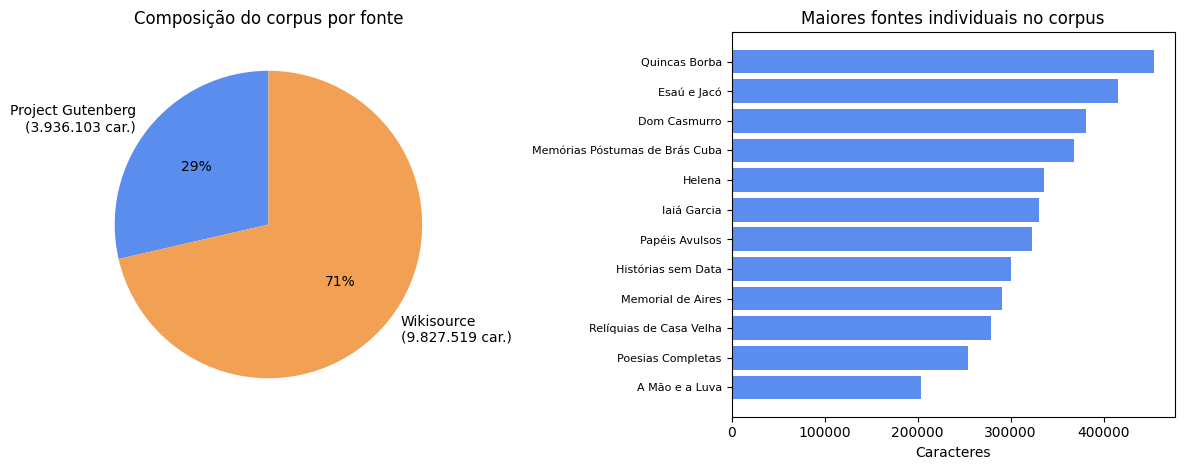

Salvo em figuras/corpus_composicao.png


In [6]:
# [código próprio]
import matplotlib.pyplot as plt
import os

os.makedirs("figuras", exist_ok=True)

# agrupa por substring em vez de igualdade exata: o caminho "huggingface" traz
# fonte="Project Gutenberg (dominio publico)"/"Wikisource (dominio publico)"
# (convencao do dataset publicado), o caminho "live" traz so "Project Gutenberg"/
# "Wikisource" -- funciona igual nos dois casos, sem depender de gutenberg_manifest/
# wikisource_manifest (que ficam vazios no caminho "huggingface")
_fontes_chars = {}
for m in manifest:
    _chave = "Project Gutenberg" if "Gutenberg" in m["fonte"] else "Wikisource"
    _fontes_chars[_chave] = _fontes_chars.get(_chave, 0) + m["n_caracteres"]
_top_fontes = sorted(manifest, key=lambda m: -m["n_caracteres"])[:12]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].pie(
    _fontes_chars.values(),
    labels=[f"{k}\n({v:,} car.)".replace(",", ".") for k, v in _fontes_chars.items()],
    autopct="%1.0f%%",
    colors=["#5b8def", "#f2a154"],
    startangle=90,
)
axes[0].set_title("Composição do corpus por fonte")

_labels = [m["titulo"][:30] for m in _top_fontes]
_vals = [m["n_caracteres"] for m in _top_fontes]
axes[1].barh(range(len(_labels)), _vals, color="#5b8def")
axes[1].set_yticks(range(len(_labels)))
axes[1].set_yticklabels(_labels, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Caracteres")
axes[1].set_title("Maiores fontes individuais no corpus")

plt.tight_layout()
plt.savefig("figuras/corpus_composicao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo em figuras/corpus_composicao.png")

## 2. Tokenização em nível de caractere

**[adaptado de terceiros]** Baseado em `data/shakespeare_char/prepare.py` do nanoGPT (Karpathy) — mesma lógica (mapa caractere→inteiro, split 90/10 treino/validação), só trocando a fonte do texto para o `input.txt` gerado nas células anteriores.

In [7]:
# [adaptado de terceiros: nanoGPT data/shakespeare_char/prepare.py, Karpathy]
import pickle
import numpy as np

with open("data/machado_char/input.txt", "r", encoding="utf-8") as f:
    data = f.read()

chars = sorted(list(set(data)))
vocab_size = len(chars)
print("vocab size:", vocab_size)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

n = len(data)
train_data = data[: int(n * 0.9)]
val_data = data[int(n * 0.9):]

train_ids = np.array(encode(train_data), dtype=np.uint16)
val_ids = np.array(encode(val_data), dtype=np.uint16)
train_ids.tofile("data/machado_char/train.bin")
val_ids.tofile("data/machado_char/val.bin")

with open("data/machado_char/meta.pkl", "wb") as f:
    pickle.dump({"vocab_size": vocab_size, "itos": itos, "stoi": stoi}, f)

print(f"train: {len(train_ids):,} tokens | val: {len(val_ids):,} tokens".replace(",", "."))

vocab size: 177
train: 12.497.818 tokens | val: 1.388.647 tokens


## 3. Arquitetura, cronograma de treino e configuração

**[adaptado de terceiros]** `config/train_machado_char.py` — cópia de `config/train_shakespeare_char.py` (nanoGPT) com `dataset='machado_char'`. `device` e `compile` vêm da detecção automática da seção 0 (`DEVICE`/`COMPILE`). Os hiperparâmetros (arquitetura "baby GPT": 6 camadas, 6 cabeças, 384 dims) são os mesmos do baseline do próprio nanoGPT para datasets pequenos — ponto de partida documentado no artigo; ajustar `max_iters`/`block_size`/`batch_size` conforme o tempo disponível. Com o corpus maior (~13,9M caracteres, seção 1), vale considerar mais iterações do que as 5000 originais — numa rodada anterior (corpus só do Gutenberg, ~3,9M caracteres) o overfitting começava perto da iteração 4000; com ~3,5x mais dados o ponto de estagnação deve vir mais tarde.

As duas células seguintes só **definem os hiperparâmetros e visualizam** a arquitetura/cronograma de LR antes de rodar o treino de verdade — não treinam nada ainda.

In [8]:
# [código próprio] hiperparâmetros do modelo/treino — únicas variáveis usadas tanto na config
# do nanoGPT quanto no diagrama de arquitetura e no cronograma de LR abaixo, pra nunca ficarem
# dessincronizados entre si
n_layer = 6
n_head = 6
n_embd = 384
block_size = 256
dropout = 0.2

# batch_size subido de 64 para 128: a memória unificada do Apple Silicon não é o gargalo (ao
# contrário de uma GPU discreta com VRAM limitada), e lote maior tende a usar a GPU com mais
# eficiência (mais MFU real). Seguro também no Colab — T4 tem folga de sobra pra um modelo de
# ~10M parâmetros.
batch_size = 128

learning_rate = 1e-3
max_iters = 15000
lr_decay_iters = 15000
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100

# avaliação/checkpoint ajustados pra reduzir overhead de wall-clock: numa rodada de 5000
# iterações, a avaliação (eval_interval=250 x eval_iters=200) chegava a consumir ~1/4 do tempo
# total. Com menos avaliações e cada uma mais barata, sobra mais tempo pra treino de fato — custo
# é uma curva de loss com menos pontos (ainda resolução de sobra pra 5000-15000 iterações).
# always_save_checkpoint=False evita reescrever um checkpoint grande em disco quando o val loss
# não melhorou.
eval_interval = 500
eval_iters = 100
always_save_checkpoint = False

print(f"n_layer={n_layer}  n_head={n_head}  n_embd={n_embd}  block_size={block_size}  "
      f"batch_size={batch_size}  max_iters={max_iters}  eval_interval={eval_interval}  "
      f"eval_iters={eval_iters}")

n_layer=6  n_head=6  n_embd=384  block_size=256  batch_size=128  max_iters=15000  eval_interval=500  eval_iters=100


### Diagrama da arquitetura

**[código próprio]** Desenha o pipeline do modelo (embeddings → blocos Transformer → head) a partir dos hiperparâmetros definidos acima, e usa a própria classe `GPT` do nanoGPT (`model.py`) só para contar os parâmetros com exatidão (sem treinar nada).

number of parameters: 10.72M
Parâmetros do modelo: 10.715.520


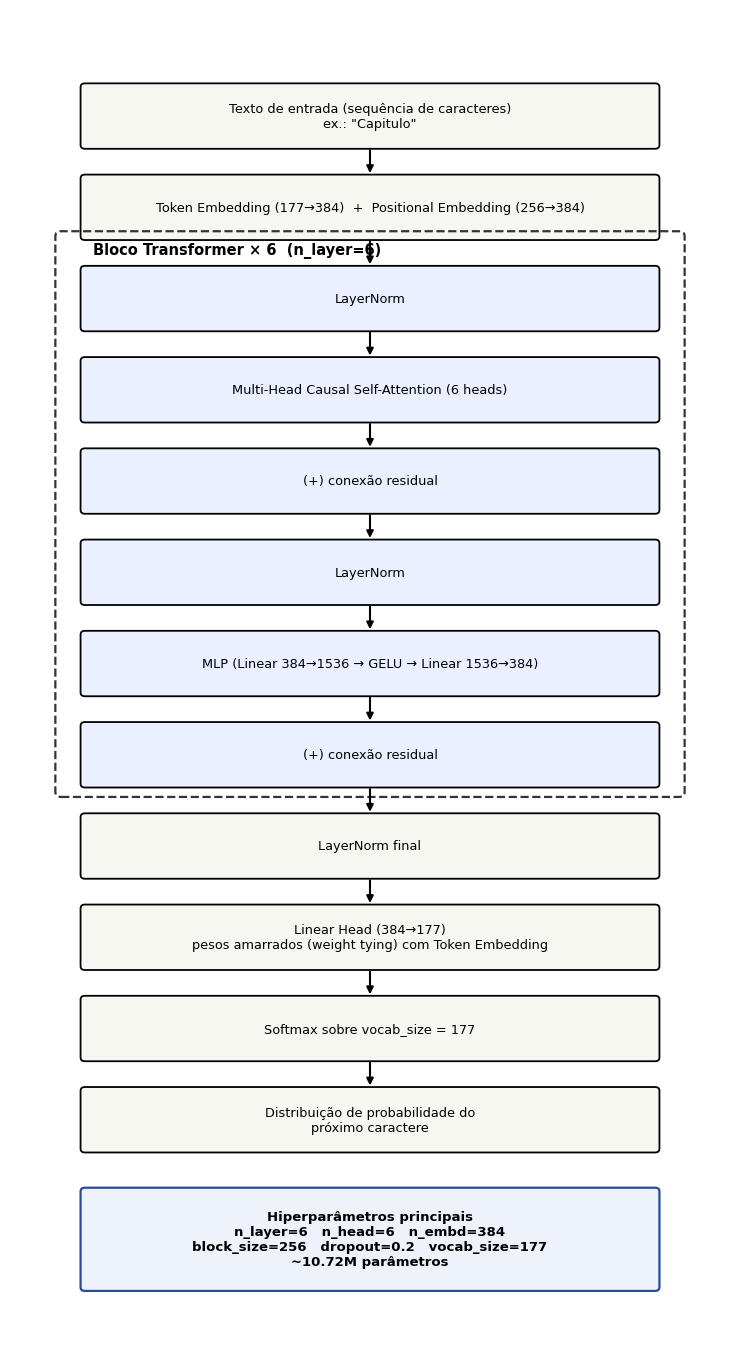

Salvo em figuras/arquitetura_gpt.png


In [9]:
# [código próprio, reaproveitando model.GPT do nanoGPT (Karpathy) só para contar parâmetros]
import sys
import matplotlib.patches as mpatches

sys.path.insert(0, ".")
from model import GPT, GPTConfig

_cfg = GPTConfig(block_size=block_size, vocab_size=vocab_size, n_layer=n_layer,
                  n_head=n_head, n_embd=n_embd, dropout=dropout, bias=True)
_tmp_model = GPT(_cfg)
n_params = _tmp_model.get_num_params()
del _tmp_model
print(f"Parâmetros do modelo: {n_params:,}".replace(",", "."))


def draw_arch_diagram(n_layer, n_head, n_embd, block_size, dropout, vocab_size, n_params, out_path):
    boxes = [
        ('Texto de entrada (sequência de caracteres)\nex.: "Capitulo"', False),
        (f"Token Embedding ({vocab_size}→{n_embd})  +  Positional Embedding ({block_size}→{n_embd})", False),
        ("LayerNorm", True),
        (f"Multi-Head Causal Self-Attention ({n_head} heads)", True),
        ("(+) conexão residual", True),
        ("LayerNorm", True),
        (f"MLP (Linear {n_embd}→{4*n_embd} → GELU → Linear {4*n_embd}→{n_embd})", True),
        ("(+) conexão residual", True),
        ("LayerNorm final", False),
        (f"Linear Head ({n_embd}→{vocab_size})\npesos amarrados (weight tying) com Token Embedding", False),
        (f"Softmax sobre vocab_size = {vocab_size}", False),
        ("Distribuição de probabilidade do\npróximo caractere", False),
    ]

    box_h, gap, W, X0 = 1.0, 0.45, 8.0, 1.0
    n = len(boxes)
    total_h = n * box_h + (n - 1) * gap
    fig, ax = plt.subplots(figsize=(7.5, (total_h + 5) * 0.62))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, total_h + 4.2)
    ax.axis("off")

    y_top = total_h + 3.0
    centers, block_idx = [], []
    for i, (label, in_block) in enumerate(boxes):
        y = y_top - i * (box_h + gap)
        fc = "#eaf0ff" if in_block else "#f7f7f2"
        box = mpatches.FancyBboxPatch((X0, y - box_h), W, box_h,
                                       boxstyle="round,pad=0.02,rounding_size=0.06",
                                       linewidth=1.3, edgecolor="black", facecolor=fc)
        ax.add_patch(box)
        ax.text(X0 + W / 2, y - box_h / 2, label, ha="center", va="center", fontsize=9.3, wrap=True)
        centers.append(y - box_h / 2)
        if in_block:
            block_idx.append(i)
        if i > 0:
            y_prev_bottom = y_top - (i - 1) * (box_h + gap) - box_h
            ax.annotate("", xy=(X0 + W / 2, y), xytext=(X0 + W / 2, y_prev_bottom),
                        arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black"))

    top_i, bot_i = block_idx[0], block_idx[-1]
    y_block_top = y_top - top_i * (box_h + gap)
    y_block_bot = y_top - bot_i * (box_h + gap) - box_h
    pad_top = 0.55
    rect = mpatches.FancyBboxPatch((X0 - 0.35, y_block_bot - 0.15), W + 0.7,
                                    (y_block_top - y_block_bot) + 0.15 + pad_top,
                                    boxstyle="round,pad=0.02,rounding_size=0.08",
                                    linewidth=1.6, linestyle="--", edgecolor="#333333", facecolor="none")
    ax.add_patch(rect)
    ax.text(X0 + 0.15, y_block_top + pad_top / 2, f"Bloco Transformer × {n_layer}  (n_layer={n_layer})",
            ha="left", va="center", fontsize=10.5, fontweight="bold")

    y_hp, hp_h = centers[-1] - box_h / 2 - 0.6, 1.6
    hp_box = mpatches.FancyBboxPatch((X0, y_hp - hp_h), W, hp_h,
                                      boxstyle="round,pad=0.02,rounding_size=0.06",
                                      linewidth=1.6, edgecolor="#2a4a9c", facecolor="#eef2fb")
    ax.add_patch(hp_box)
    hp_text = (f"Hiperparâmetros principais\n"
               f"n_layer={n_layer}   n_head={n_head}   n_embd={n_embd}\n"
               f"block_size={block_size}   dropout={dropout}   vocab_size={vocab_size}\n"
               f"~{n_params/1e6:.2f}M parâmetros")
    ax.text(X0 + W / 2, y_hp - hp_h / 2, hp_text, ha="center", va="center", fontsize=9.5, fontweight="bold")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


draw_arch_diagram(n_layer, n_head, n_embd, block_size, dropout, vocab_size, n_params, "figuras/arquitetura_gpt.png")
print("Salvo em figuras/arquitetura_gpt.png")

### Cronograma de learning rate

**[adaptado de terceiros]** Réplica exata da função `get_lr(it)` de `train.py` (nanoGPT): warmup linear seguido de decaimento cosseno. Só visualiza o cronograma antes do treino — não é usada de fato aqui (o `train.py` já calcula isso internamente).

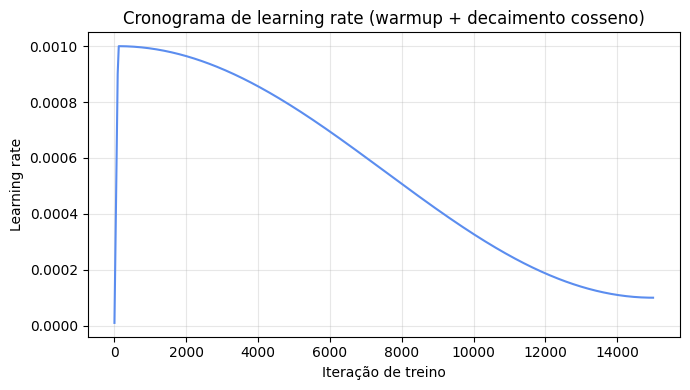

Salvo em figuras/lr_schedule.png


In [10]:
# [adaptado de terceiros: nanoGPT train.py, função get_lr, Karpathy]
import math

def get_lr(it):
    if it < warmup_iters:
        return learning_rate * (it + 1) / (warmup_iters + 1)
    if it > lr_decay_iters:
        return min_lr
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

_iters = list(range(0, max_iters + 1, max(1, max_iters // 500)))
_lrs = [get_lr(i) for i in _iters]

plt.figure(figsize=(7, 4))
plt.plot(_iters, _lrs, color="#5b8def")
plt.xlabel("Iteração de treino")
plt.ylabel("Learning rate")
plt.title("Cronograma de learning rate (warmup + decaimento cosseno)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/lr_schedule.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo em figuras/lr_schedule.png")

### Treino

Grava a config a partir das variáveis definidas acima e roda o treino de fato — `2>&1 | tee train_log.txt` além de mostrar a saída ao vivo, salva o log em arquivo para as células de avaliação (seção 4) parsearem as curvas de loss/perplexidade depois.

In [11]:
# [adaptado de terceiros: nanoGPT config/train_shakespeare_char.py, Karpathy]
# device/compile vêm da detecção de hardware feita na seção 0 (DEVICE/COMPILE);
# os demais hiperparâmetros (incluindo eval_interval/eval_iters/always_save_checkpoint,
# otimizados pra velocidade) vêm da célula de hiperparâmetros acima
config = f'''
out_dir = 'out-machado-char'
eval_interval = {eval_interval}
eval_iters = {eval_iters}
log_interval = 10
always_save_checkpoint = {always_save_checkpoint}

wandb_log = False

dataset = 'machado_char'
gradient_accumulation_steps = 1
batch_size = {batch_size}
block_size = {block_size}

n_layer = {n_layer}
n_head = {n_head}
n_embd = {n_embd}
dropout = {dropout}

learning_rate = {learning_rate}
max_iters = {max_iters}
lr_decay_iters = {lr_decay_iters}
min_lr = {min_lr}
beta2 = {beta2}
warmup_iters = {warmup_iters}

device = '{DEVICE}'
compile = {COMPILE}
'''
with open("config/train_machado_char.py", "w") as f:
    f.write(config)

!python train.py config/train_machado_char.py 2>&1 | tee train_log.txt

W0927 16:23:38.384000 3562 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
Overriding config with config/train_machado_char.py:

out_dir = 'out-machado-char'
eval_interval = 500
eval_iters = 100
log_interval = 10
always_save_checkpoint = False

wandb_log = False

dataset = 'machado_char'
gradient_accumulation_steps = 1
batch_size = 128
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 0.001
max_iters = 15000
lr_decay_iters = 15000
min_lr = 0.0001
beta2 = 0.99
warmup_iters = 100

device = 'cuda'
compile = True

tokens per iteration will be: 32,768
found vocab_size = 177 (inside data/machado_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 10.69M
num decayed parameter tensors: 26, with 10,783,104 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True
compiling the model... (takes a ~minute)
step 0: train loss 5.1939, val loss 5.1961
iter 0: loss 5.1967, 

## 4. Avaliação quantitativa

**[código próprio]** Faz o parsing de `train_log.txt` (gerado pela célula de treino acima) para extrair `train loss`/`val loss` a cada `eval_interval`, calcula a perplexidade (`exp(loss)`) e plota as duas curvas — sem precisar copiar números manualmente do log.

In [12]:
# [código próprio]
import re

with open("train_log.txt", "r", errors="ignore") as f:
    _log = f.read()

_pat = re.compile(r"step (\d+): train loss ([\d.]+), val loss ([\d.]+)")
loss_points = [(int(m.group(1)), float(m.group(2)), float(m.group(3))) for m in _pat.finditer(_log)]

if not loss_points:
    print("Nenhum ponto encontrado em train_log.txt — rode a célula de treino primeiro.")
else:
    iters_l = [p[0] for p in loss_points]
    train_losses = [p[1] for p in loss_points]
    val_losses = [p[2] for p in loss_points]

    best_i = min(range(len(loss_points)), key=lambda i: val_losses[i])
    best_iter, best_train, best_val = loss_points[best_i]
    val_loss_final = val_losses[-1]

    print(f"{len(loss_points)} pontos de avaliação (a cada eval_interval).")
    print(f"Melhor val loss: {best_val:.4f} na iteração {best_iter} (perplexidade ≈ {math.exp(best_val):.2f})")
    print(f"Val loss no checkpoint final (última iteração, {iters_l[-1]}): {val_loss_final:.4f} "
          f"(perplexidade ≈ {math.exp(val_loss_final):.2f})")

31 pontos de avaliação (a cada eval_interval).
Melhor val loss: 1.1049 na iteração 15000 (perplexidade ≈ 3.02)
Val loss no checkpoint final (última iteração, 15000): 1.1049 (perplexidade ≈ 3.02)


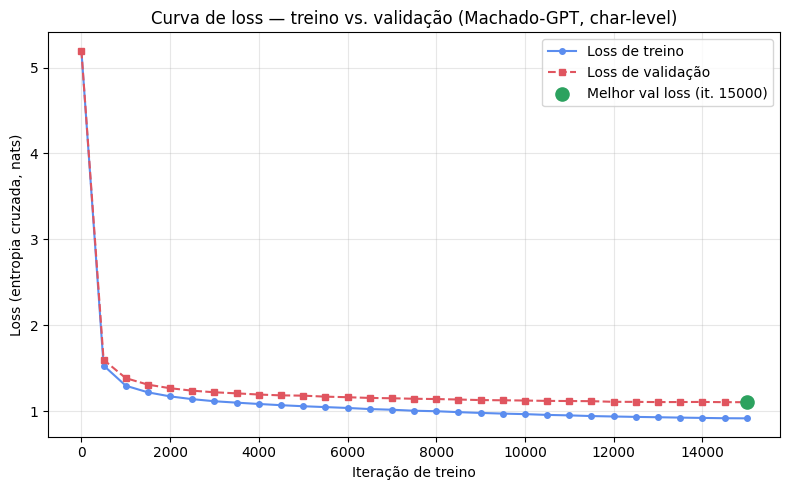

Salvo em figuras/loss_curve.png


In [13]:
# [código próprio] curva de loss
plt.figure(figsize=(8, 5))
plt.plot(iters_l, train_losses, "o-", color="#5b8def", label="Loss de treino", markersize=4)
plt.plot(iters_l, val_losses, "s--", color="#e0555f", label="Loss de validação", markersize=4)
plt.scatter([best_iter], [best_val], color="#2ca25f", zorder=5, s=90,
            label=f"Melhor val loss (it. {best_iter})")
plt.xlabel("Iteração de treino")
plt.ylabel("Loss (entropia cruzada, nats)")
plt.title("Curva de loss — treino vs. validação (Machado-GPT, char-level)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo em figuras/loss_curve.png")

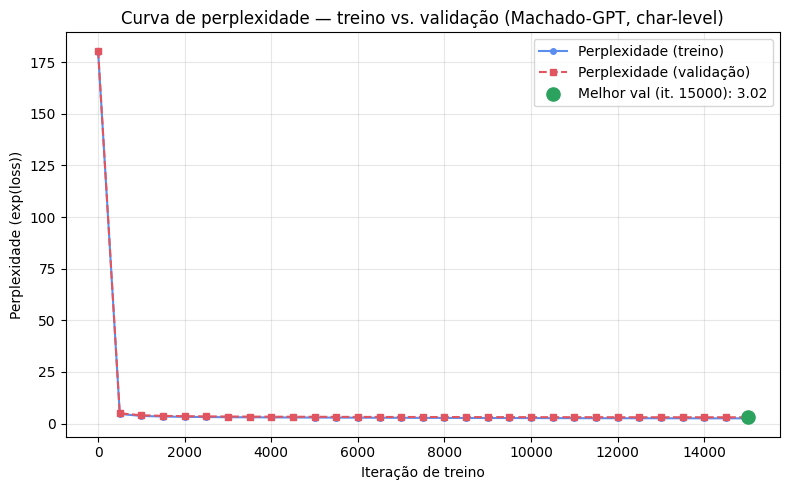

Salvo em figuras/perplexity_curve.png


In [14]:
# [código próprio] curva de perplexidade
train_ppl = [math.exp(v) for v in train_losses]
val_ppl = [math.exp(v) for v in val_losses]

plt.figure(figsize=(8, 5))
plt.plot(iters_l, train_ppl, "o-", color="#5b8def", label="Perplexidade (treino)", markersize=4)
plt.plot(iters_l, val_ppl, "s--", color="#e0555f", label="Perplexidade (validação)", markersize=4)
plt.scatter([best_iter], [math.exp(best_val)], color="#2ca25f", zorder=5, s=90,
            label=f"Melhor val (it. {best_iter}): {math.exp(best_val):.2f}")
plt.xlabel("Iteração de treino")
plt.ylabel("Perplexidade (exp(loss))")
plt.title("Curva de perplexidade — treino vs. validação (Machado-GPT, char-level)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/perplexity_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo em figuras/perplexity_curve.png")

## 5. Avaliação qualitativa — geração de texto

**[código de terceiros]** `sample.py` (nanoGPT) carrega o checkpoint e gera texto a partir de um prompt. Usado aqui sem modificação, só apontando para o checkpoint treinado.

In [15]:
# --device vem da detecção de hardware da seção 0 (DEVICE)
!python sample.py --out_dir=out-machado-char --device={DEVICE} --num_samples=3 --max_new_tokens=400 --start="Capitu"

Overriding: out_dir = out-machado-char
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 400
Overriding: start = Capitu
number of parameters: 10.69M
Loading meta from data/machado_char/meta.pkl...
Capitu fel-a sentar e deu alguns passos na sala, e foi esperal-a á porta da sala, com a mais vermelha. Helena recolheu-se ao quarto, mas sorriu-se e foi realmente espantal-a. Esta palavra, apertada, resolveu aproximal-a da sala pelo teto. Estacio estava sentado na cama, para não attender á mulher a um livro de sorriso. Luiz Alves assomou ao pé da cama,
sem lhe responder nada.

--Mas como é que eu não de
---------------
Capitu deu-me um salto, que me apeou e soube que a vida estava no sentido de D. Carmo.

— Não me falou do homem, disse ela.

— Disse tudo.

— Que é?

— É ele mesmo.

— Alguma coisa, mas não sei. Amanhã falamos de coisas bonitas.

— Há de ser sua irmã.

— Amanhã não.

— Não, disse Aguiar; estou consolada de mim.

— Mas falemo-nos de outra coisa..

## 6. Extensão: rumo a perguntas e respostas no universo machadiano

**[discussão própria, para o artigo]** O modelo treinado acima é puramente gerativo em nível de caractere (completa texto no estilo de Machado, sem noção de pergunta/resposta). Para estender esse projeto a um sistema de Q&A sobre as obras, duas direções plausíveis:

1. **Fine-tuning supervisionado** do checkpoint em pares (pergunta, resposta) construídos manualmente ou com apoio de um LLM maior, formatando o prompt como `Pergunta: ... Resposta:` — mudaria o objetivo de completude livre para completude condicionada.
2. **RAG (Retrieval-Augmented Generation)**: indexar o corpus (por capítulo/obra) com embeddings e recuperar os trechos mais relevantes para compor o contexto antes da geração — mais viável que o fine-tuning puro, já que o modelo baby-GPT em nível de caractere tem pouquíssima capacidade de memorização factual robusta.

Nenhuma das duas foi implementada nesta entrega — fica registrada como direção de trabalho futuro no artigo, conforme pedido no enunciado ("como ele poderia ser estendido para responder a questões no universo Machado de Assis").